# KMEANS CON DATASET IRIS

## IMPORTAMOS LIBRERIAS NECESARIAS

In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

## CARGAMOS DATASET IRIS

In [2]:
df = sns.load_dataset('iris')
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


# EDA

In [3]:
df.shape

(150, 5)

In [4]:
df.dtypes

,0
sepal_length,float64
sepal_width,float64
petal_length,float64
petal_width,float64
species,object


In [5]:
df.species.value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


In [6]:
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


# CLUSTERING USANDO K-MEANS

## IDENTIFICAR VARIABLE X

In [7]:
X = df.select_dtypes(include=[np.number])

# ESCALAMIENTO DE DATOS

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# CREAMOS MODELO CON KMEANS

In [9]:
K = 3
kmeans = KMeans(n_clusters=K, random_state=42)
kmeans.fit(X_scaled)
labels = kmeans.labels_
labels

array([1, 2, 2, 2, 1, 1, 1, 1, 2, 2, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 2, 1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 1, 1, 2, 1, 1, 2, 2, 1,
       1, 2, 1, 2, 1, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

# VISUALIZAMOS LOS CLUSTERS

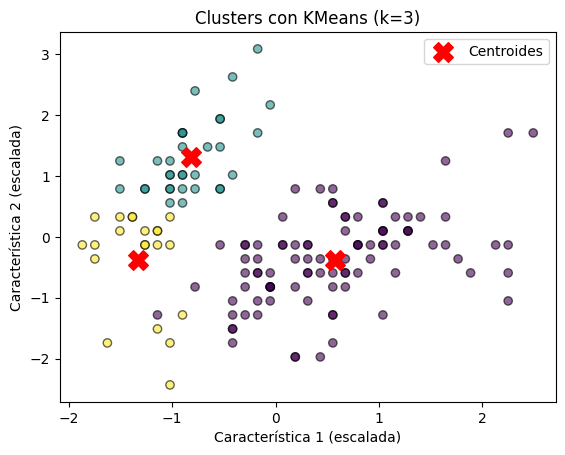

In [10]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis', alpha=0.6, edgecolors='k')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='red', marker='X', label='Centroides')
plt.xlabel('Característica 1 (escalada)')
plt.ylabel('Característica 2 (escalada)')
plt.title(f'Clusters con KMeans (k={K})')
plt.legend()
plt.show()

# COMO EVALUAMOS EL RESULTADO

# 📊 Silhouette Score (Coeficiente de Silueta)

El **Silhouette Score** es una métrica utilizada para evaluar la calidad de un modelo de **clustering** (aprendizaje no supervisado).

Permite medir qué tan bien están agrupados los datos, considerando:

- La **cohesión** (qué tan cerca están los puntos dentro del mismo cluster)
- La **separación** (qué tan lejos están de otros clusters)

---

## 🧠 Intuición del Silhouette Score

Para cada punto:

- Se calcula qué tan cerca está de los puntos de su propio cluster
- Se compara con la distancia al cluster más cercano

👉 La idea es verificar si el punto está **bien asignado** o debería pertenecer a otro grupo.

---

## 📐 Fórmula

El coeficiente de silueta para un punto se define como:

s = (b - a) / max(a, b)

Donde:

- **a** = distancia promedio del punto a los demás puntos de su mismo cluster
- **b** = distancia promedio del punto al cluster más cercano (al que no pertenece)

---

## 📊 Rango de valores

El Silhouette Score toma valores entre:

- **-1 ≤ s ≤ 1**

---

## 📈 Interpretación

| Valor | Significado |
|------|------------|
| **Cercano a 1** | Punto bien asignado, clusters bien separados |
| **Cercano a 0** | Punto en el límite entre clusters |
| **Cercano a -1** | Punto mal asignado, probablemente pertenece a otro cluster |

---

## 🎯 Interpretación global del modelo

El Silhouette Score total se obtiene como el promedio de todos los puntos:

- **Score alto (≈ 0.7 - 1.0)** → Clusters bien definidos
- **Score medio (≈ 0.3 - 0.7)** → Estructura aceptable
- **Score bajo (< 0.3)** → Clusters débiles o solapados
- **Score negativo** → Agrupamiento incorrecto

---

## 🧩 Importancia

El Silhouette Score es útil para:

- Evaluar la calidad del clustering
- Comparar diferentes algoritmos (KMeans, DBSCAN, etc.)
- Determinar el número óptimo de clusters (K)

---

## ⚙️ Ventajas

✔ No requiere etiquetas reales  
✔ Fácil de interpretar  
✔ Útil para validación de clustering  

---

## ⚠️ Limitaciones

❌ Sensible a la forma de los clusters  
❌ No funciona bien con clusters de densidad variable  
❌ Puede ser costoso computacionalmente en datasets grandes  

---

## 📌 Conclusión

El Silhouette Score es una de las métricas más importantes para evaluar modelos de clustering, ya que permite medir simultáneamente la **cohesión interna** y la **separación entre grupos**, ayudando a validar la calidad del modelo sin necesidad de etiquetas.

In [11]:
silhouette_value = silhouette_score(X_scaled,labels)
print(f'Coeficiente de Silueta para k={K} : {silhouette_value}:.4f')

Coeficiente de Silueta para k=3 : 0.4798814508199818:.4f
